In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data"
REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

mc = pd.read_csv(DATA_DIR / "monte_carlo_scenarios.csv")

print("Monte Carlo Shape:", mc.shape)
display(mc.head())

Monte Carlo Shape: (1000, 9)


,ScenarioID,ParallelShift_bps,TwistFactor_bps,ButterflyFactor_bps,PnL_DurationEffect_INR,PnL_ConvexityEffect_INR,PnL_Total_INR,PnL_Pct,VaR_Contribution
0,1,-50.28,-43.61,-6.73,677553.73,17857.27,695411.01,2.1691,695411.01
1,2,-103.23,-5.91,3.08,1391064.43,75270.04,1466334.46,4.5738,1466334.46
2,3,-48.20,35.50,-36.27,649560.04,16412.18,665972.21,2.0773,665972.21
3,4,43.03,22.37,61.30,-579832.59,13077.75,-566754.84,-1.7678,566754.84
4,5,-5.52,-51.75,-16.79,74315.99,214.83,74530.82,0.2325,74530.82


In [4]:
summary_stats = mc[
    [
        "ParallelShift_bps",
        "TwistFactor_bps",
        "ButterflyFactor_bps",
        "PnL_Total_INR",
        "PnL_Pct"
    ]
].describe()

display(summary_stats)

,ParallelShift_bps,TwistFactor_bps,ButterflyFactor_bps,PnL_Total_INR,PnL_Pct
count,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000
mean,-1.464090,1.892620,1.350360,8.416630e+04,0.262534
std,95.553416,49.856914,30.392441,1.293117e+06,4.033510
min,-369.780000,-142.300000,-108.820000,-3.399504e+06,-10.603800
25%,-67.702500,-31.755000,-17.902500,-8.411124e+05,-2.623575
50%,-4.660000,3.165000,1.315000,6.295529e+04,0.196400
75%,64.610000,35.455000,21.097500,9.446568e+05,2.946625
max,299.210000,158.980000,99.160000,5.948564e+06,18.554900


In [5]:
var_95 = mc["PnL_Total_INR"].quantile(0.05)
var_99 = mc["PnL_Total_INR"].quantile(0.01)

cvar_95 = mc[mc["PnL_Total_INR"] <= var_95]["PnL_Total_INR"].mean()
cvar_99 = mc[mc["PnL_Total_INR"] <= var_99]["PnL_Total_INR"].mean()

print(f"VaR 95%: ₹{var_95:,.2f}")
print(f"CVaR 95%: ₹{cvar_95:,.2f}")
print(f"VaR 99%: ₹{var_99:,.2f}")
print(f"CVaR 99%: ₹{cvar_99:,.2f}")

VaR 95%: ₹-1,976,671.43
CVaR 95%: ₹-2,377,153.69
VaR 99%: ₹-2,517,270.96
CVaR 99%: ₹-2,999,457.15


In [6]:
var_summary = pd.DataFrame({
    "Risk Metric": [
        "VaR 95%",
        "CVaR 95%",
        "VaR 99%",
        "CVaR 99%",
        "Best Scenario P&L",
        "Worst Scenario P&L",
        "Average Scenario P&L"
    ],
    "Value_INR": [
        var_95,
        cvar_95,
        var_99,
        cvar_99,
        mc["PnL_Total_INR"].max(),
        mc["PnL_Total_INR"].min(),
        mc["PnL_Total_INR"].mean()
    ]
})

display(var_summary)

,Risk Metric,Value_INR
0,VaR 95%,-1.976671e+06
1,CVaR 95%,-2.377154e+06
2,VaR 99%,-2.517271e+06
3,CVaR 99%,-2.999457e+06
4,Best Scenario P&L,5.948564e+06
5,Worst Scenario P&L,-3.399504e+06
6,Average Scenario P&L,8.416630e+04


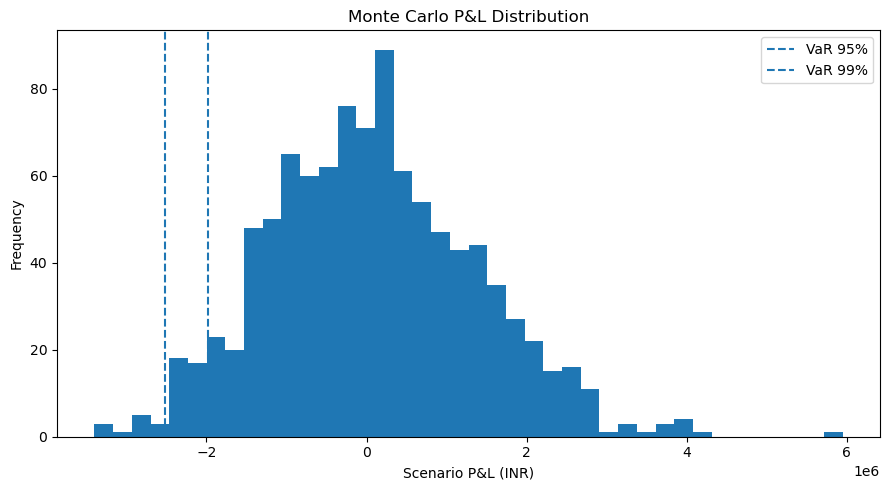

In [7]:
plt.figure(figsize=(9, 5))

plt.hist(mc["PnL_Total_INR"], bins=40)

plt.axvline(var_95, linestyle="--", label="VaR 95%")
plt.axvline(var_99, linestyle="--", label="VaR 99%")

plt.title("Monte Carlo P&L Distribution")
plt.xlabel("Scenario P&L (INR)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

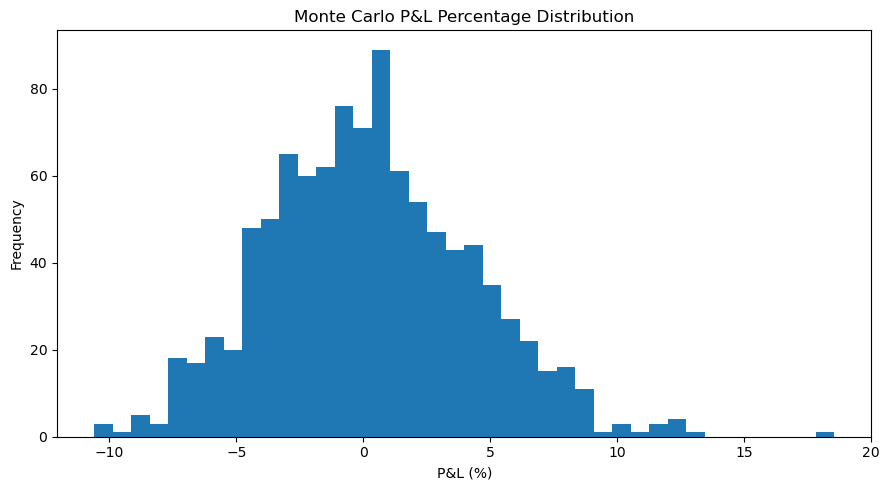

In [8]:
plt.figure(figsize=(9, 5))

plt.hist(mc["PnL_Pct"], bins=40)

plt.title("Monte Carlo P&L Percentage Distribution")
plt.xlabel("P&L (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [9]:
worst_10 = (
    mc.sort_values("PnL_Total_INR")
    .head(10)
)

display(worst_10)

,ScenarioID,ParallelShift_bps,TwistFactor_bps,ButterflyFactor_bps,PnL_DurationEffect_INR,PnL_ConvexityEffect_INR,PnL_Total_INR,PnL_Pct,VaR_Contribution
865,866,299.21,-29.88,-26.84,-4031810.81,632306.90,-3399503.91,-10.6038,3399503.91
446,447,287.87,6.46,-9.38,-3879027.35,585292.98,-3293734.37,-10.2739,3293734.37
547,548,278.70,87.55,-18.61,-3755455.28,548596.23,-3206859.05,-10.0029,3206859.05
444,445,259.51,-16.29,34.03,-3496840.25,475640.93,-3021199.32,-9.4238,3021199.32
270,271,250.23,66.97,-2.63,-3371831.55,442241.38,-2929590.18,-9.1380,2929590.18
795,796,248.33,64.99,72.65,-3346275.20,435562.96,-2910712.24,-9.0791,2910712.24
699,700,247.96,-44.76,-45.62,-3341276.95,434262.75,-2907014.20,-9.0676,2907014.20
417,418,246.84,61.77,-9.18,-3326204.85,430353.77,-2895851.07,-9.0328,2895851.07
870,871,240.22,-40.39,15.00,-3236900.43,407555.08,-2829345.35,-8.8253,2829345.35
240,241,217.89,-0.12,4.60,-2936086.23,335324.47,-2600761.77,-8.1123,2600761.77


In [10]:
best_10 = (
    mc.sort_values("PnL_Total_INR", ascending=False)
    .head(10)
)

display(best_10)

,ScenarioID,ParallelShift_bps,TwistFactor_bps,ButterflyFactor_bps,PnL_DurationEffect_INR,PnL_ConvexityEffect_INR,PnL_Total_INR,PnL_Pct,VaR_Contribution
289,290,-369.78,49.15,6.99,4982794.41,965769.69,5948564.10,18.5549,5948564.10
216,217,-269.28,0.67,-5.49,3628586.76,512156.46,4140743.21,12.9159,4140743.21
20,21,-265.36,5.80,-23.12,3575768.72,497354.98,4073123.71,12.7049,4073123.71
302,303,-262.01,23.01,10.73,3530610.22,484872.08,4015482.31,12.5252,4015482.31
679,680,-260.15,96.03,31.84,3505452.38,477986.66,3983439.04,12.4252,3983439.04
59,60,-252.20,39.52,44.30,3398367.25,449229.48,3847596.74,12.0015,3847596.74
669,670,-250.12,11.12,-49.62,3370360.84,441855.67,3812216.51,11.8911,3812216.51
549,550,-248.12,95.53,-18.03,3343411.65,434817.82,3778229.47,11.7851,3778229.47
912,913,-244.07,-18.36,4.61,3288805.40,420730.49,3709535.89,11.5708,3709535.89
398,399,-232.72,6.24,-10.14,3135947.65,382529.77,3518477.42,10.9749,3518477.42


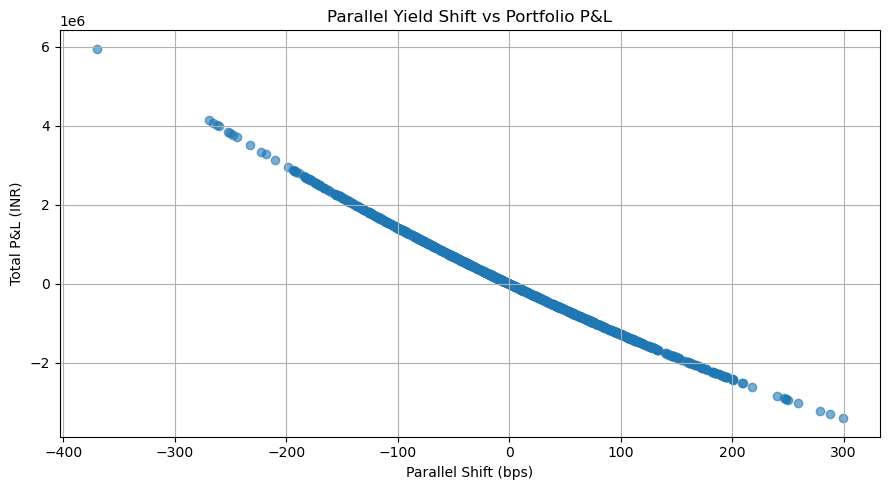

In [11]:
plt.figure(figsize=(9, 5))

plt.scatter(
    mc["ParallelShift_bps"],
    mc["PnL_Total_INR"],
    alpha=0.6
)

plt.title("Parallel Yield Shift vs Portfolio P&L")
plt.xlabel("Parallel Shift (bps)")
plt.ylabel("Total P&L (INR)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
factor_summary = pd.DataFrame({
    "Factor": [
        "Parallel Shift",
        "Twist Factor",
        "Butterfly Factor"
    ],
    "Mean_bps": [
        mc["ParallelShift_bps"].mean(),
        mc["TwistFactor_bps"].mean(),
        mc["ButterflyFactor_bps"].mean()
    ],
    "StdDev_bps": [
        mc["ParallelShift_bps"].std(),
        mc["TwistFactor_bps"].std(),
        mc["ButterflyFactor_bps"].std()
    ],
    "Min_bps": [
        mc["ParallelShift_bps"].min(),
        mc["TwistFactor_bps"].min(),
        mc["ButterflyFactor_bps"].min()
    ],
    "Max_bps": [
        mc["ParallelShift_bps"].max(),
        mc["TwistFactor_bps"].max(),
        mc["ButterflyFactor_bps"].max()
    ]
})

display(factor_summary)

,Factor,Mean_bps,StdDev_bps,Min_bps,Max_bps
0,Parallel Shift,-1.46409,95.553416,-369.78,299.21
1,Twist Factor,1.89262,49.856914,-142.30,158.98
2,Butterfly Factor,1.35036,30.392441,-108.82,99.16


In [13]:
var_summary.to_csv(REPORTS_DIR / "monte_carlo_var_summary_day6.csv", index=False)
worst_10.to_csv(REPORTS_DIR / "worst_10_mc_scenarios_day6.csv", index=False)
best_10.to_csv(REPORTS_DIR / "best_10_mc_scenarios_day6.csv", index=False)
factor_summary.to_csv(REPORTS_DIR / "mc_factor_summary_day6.csv", index=False)

print("Day 6 Monte Carlo VaR outputs saved successfully.")

Day 6 Monte Carlo VaR outputs saved successfully.
